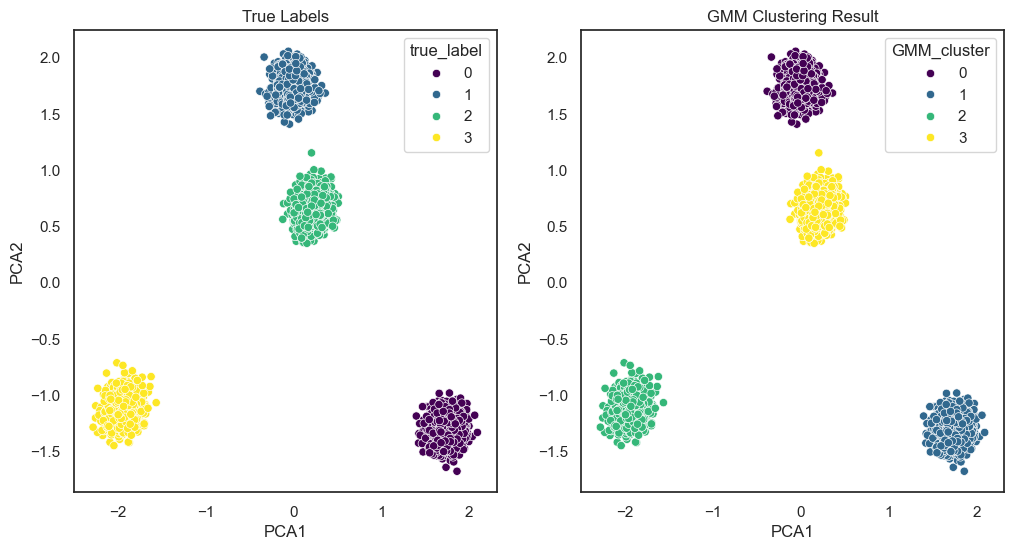

In [1]:
import pandas as pd
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

sns.set(style="white", palette="muted", color_codes=True)

n_samples = 5000
n_features = 4
n_clusters = 4

X, y = make_blobs(n_samples=n_samples, n_features=n_features, centers=n_clusters, cluster_std=0.60, random_state=42)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

df = pd.DataFrame(X_scaled, columns=[f'Feature_{i+1}' for i in range(n_features)])
df['true_label'] = y

gmm = GaussianMixture(n_components=n_clusters, covariance_type='full', random_state=42)
gmm.fit(X_scaled)

labels = gmm.predict(X_scaled)

df['GMM_cluster'] = labels

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

plt.figure(figsize=(12, 6))


plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='true_label', palette='viridis', legend='full')
plt.title('True Labels')

plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='GMM_cluster', palette='viridis', legend='full')
plt.title('GMM Clustering Result')

plt.show()

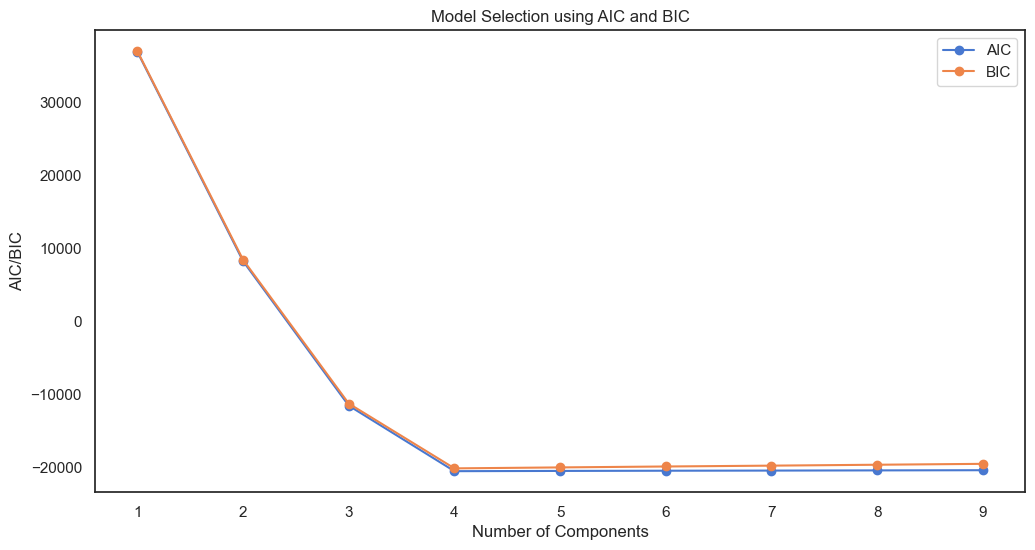

In [3]:
n_components_range = range(1, 10)
aic = []
bic = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=42)
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))

plt.figure(figsize=(12, 6))
plt.plot(n_components_range, aic, label='AIC', marker='o')
plt.plot(n_components_range, bic, label='BIC', marker='o')
plt.xlabel('Number of Components')
plt.ylabel('AIC/BIC')
plt.legend()
plt.title('Model Selection using AIC and BIC')
plt.show()

Best number of components: 4


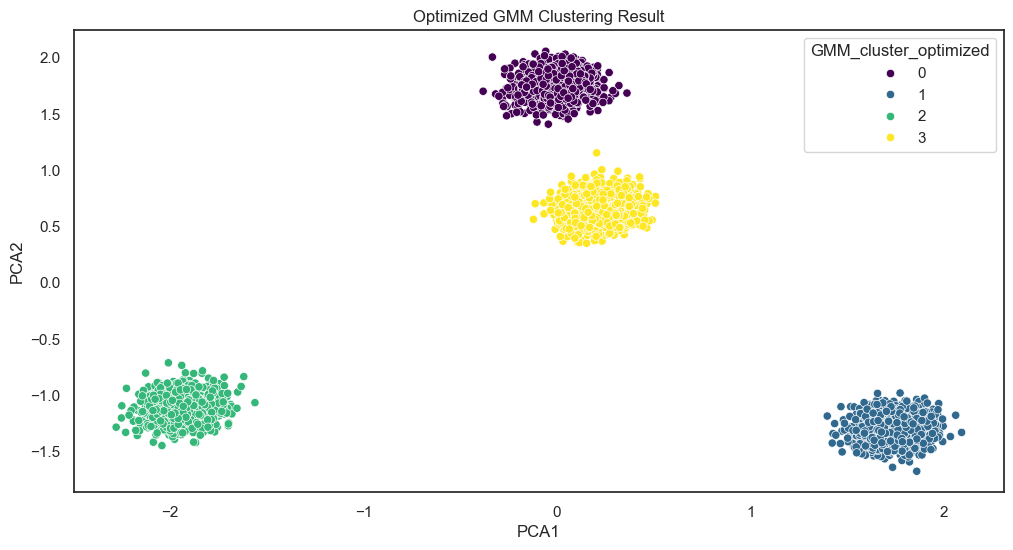

In [5]:
best_n_components = n_components_range[np.argmin(bic)]
print(f'Best number of components: {best_n_components}')

gmm = GaussianMixture(n_components=best_n_components, covariance_type='full', random_state=42)
gmm.fit(X_scaled)
labels_optimized = gmm.predict(X_scaled)

df['GMM_cluster_optimized'] = labels_optimized

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='PCA1', y='PCA2', hue='GMM_cluster_optimized', palette='viridis', legend='full')
plt.title('Optimized GMM Clustering Result')
plt.show()